# A Practical Guide to Data Augmentation in PyTorch

Getting high accuracy from a deep learning model is tough when the dataset is limited. The model overfits fast, fails to generalize beyond training data, and accuracy remains low. Data augmentation is the primary solution to this problem.

This notebook covers:

1. What data augmentation is and why it matters
2. Types of augmentation strategies
3. Basic augmentation pipelines with `torchvision.transforms`
4. Modern API: `torchvision.transforms.v2`
5. Advanced libraries: Albumentations and Kornia
6. Sample mixing: Mixup, CutMix, and Cutout
7. Policy-based augmentation: RandAugment and AutoAugment
8. Testing whether augmentation actually helps

## 0. Installation and Environment Setup

Install all required libraries before proceeding.

In [ ]:
# Install required libraries
# Run this cell once if any package is missing
# !pip install torch torchvision albumentations kornia matplotlib numpy

In [30]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder


print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

PyTorch version : 2.11.0+cu130
Torchvision     : 0.26.0+cu130
CUDA available  : True


## 1. What Is Data Augmentation?

Data augmentation is the process of creating new training examples by modifying existing ones without changing the label.

**Key benefits:**

- Expands the effective size of the training set
- Forces the model to learn invariant, generalizable features
- Acts as a regularizer, reducing overfitting
- Improves robustness to real-world variation in lighting, angle, occlusion, etc.

**Important constraint:** An augmentation must preserve the semantic label. For example, flipping a photo of a cat still shows a cat. But rotating the digit `6` by 180 degrees turns it into a `9` — that would break the label.

The goal is to increase diversity without breaking the connection between input and label.

## 2. Types of Data Augmentation

Augmentation techniques can be grouped into five broad categories based on what they change and why.

| Category | What It Changes | Purpose |
|---|---|---|
| Geometric transformations | Spatial layout | Position/scale/orientation invariance |
| Color and appearance | Pixel intensities | Lighting/sensor variation robustness |
| Occlusion / region-based | Hides parts of the image | Forces reasoning with incomplete data |
| Sample mixing | Blends two images and labels | Strong regularization |
| Policy-based / learned | Learned or searched strategies | Automated optimal policy discovery |

### 2.1 Geometric Transformations

These change the spatial layout of an image. They teach the model to be invariant to position, scale, and orientation.

Common transforms:
- `RandomHorizontalFlip`, `RandomVerticalFlip` — mirror along an axis
- `RandomRotation` — rotate by small angles
- `RandomCrop`, `CenterCrop` — train on partial views
- `RandomAffine`, `RandomPerspective` — apply broader spatial distortions

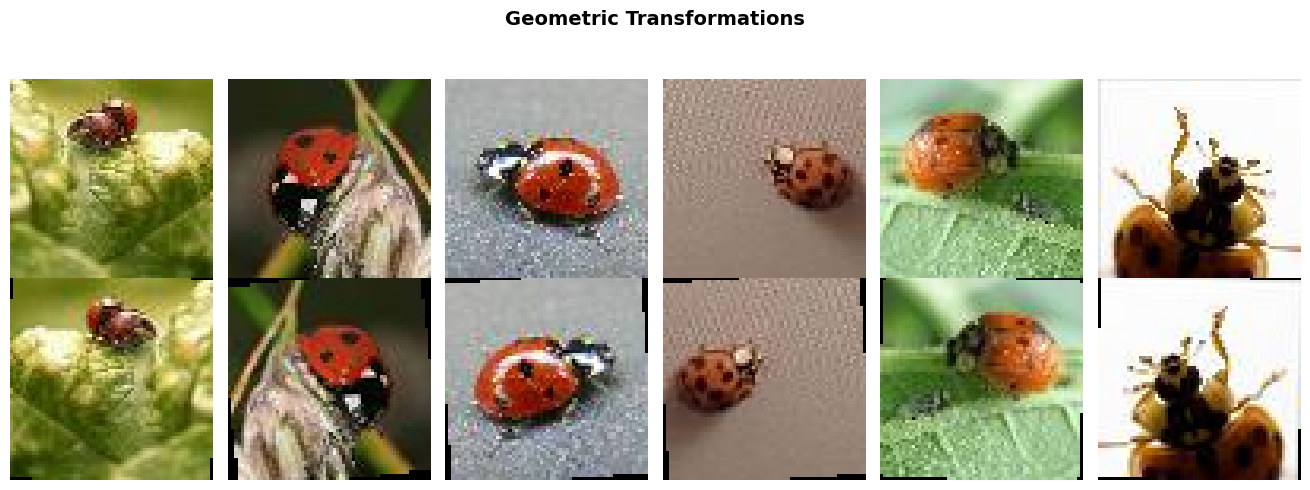

In [31]:
from torchvision.datasets import CIFAR10
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Download from: http://cs231n.stanford.edu/tiny-imagenet-200.zip
raw_dataset = ImageFolder(root='./data/tiny-imagenet-200/train/n02165456/', transform=None)

def show_transform_grid(transform, dataset, title='Augmentation', num_images=6):
    fig, axs = plt.subplots(2, num_images, figsize=(num_images * 2.2, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i in range(num_images):
        pil_img, label = dataset[i]
        aug_img = transform(pil_img)
        axs[0, i].imshow(pil_img)
        axs[0, i].axis('off')
        axs[1, i].imshow(aug_img)
        axs[1, i].axis('off')
    axs[0, 0].set_ylabel('Original', fontsize=10)
    axs[1, 0].set_ylabel('Augmented', fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# BETTER: Gentler transforms + crop AFTER rotation to remove black corners
geo_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.9),  
    transforms.RandomRotation(degrees=10, interpolation=transforms.InterpolationMode.BICUBIC), 
    # transforms.RandomCrop(32, padding=4), 
])

show_transform_grid(geo_transform, raw_dataset, title='Geometric Transformations')

### 2.2 Color and Appearance Adjustments

These simulate changes in lighting, camera sensors, and image quality. They help the model ignore irrelevant pixel-level variation.

Common transforms:
- `ColorJitter` — adjust brightness, contrast, saturation, hue
- `Grayscale` — remove color information entirely
- `GaussianBlur` — simulate out-of-focus or motion blur
- `RandomSolarize`, `RandomPosterize` — alter pixel intensity patterns

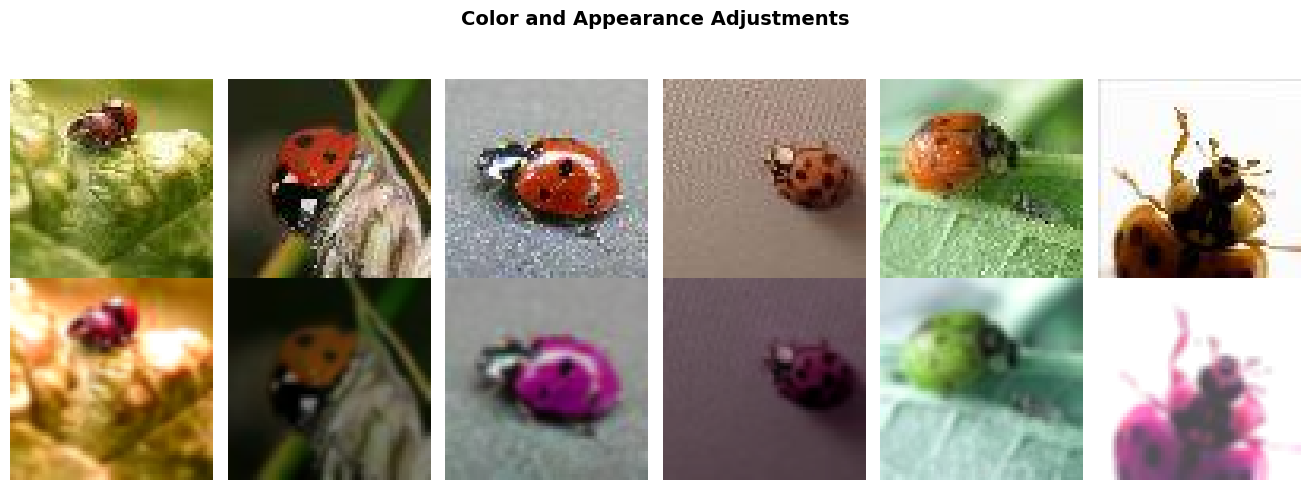

In [32]:
color_transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
])

show_transform_grid(color_transform, raw_dataset, title='Color and Appearance Adjustments')

### 2.3 Occlusion and Region-Based Augmentations

These techniques hide or remove regions of the input, forcing the model to reason using incomplete information. This prevents over-reliance on any single spatial region.

Common transforms:
- `RandomErasing` (torchvision) — erases a random rectangle in the image tensor
- `Cutout` — erases a fixed-size square (often implemented manually)
- `Hide-and-Seek` — hides multiple patches at random

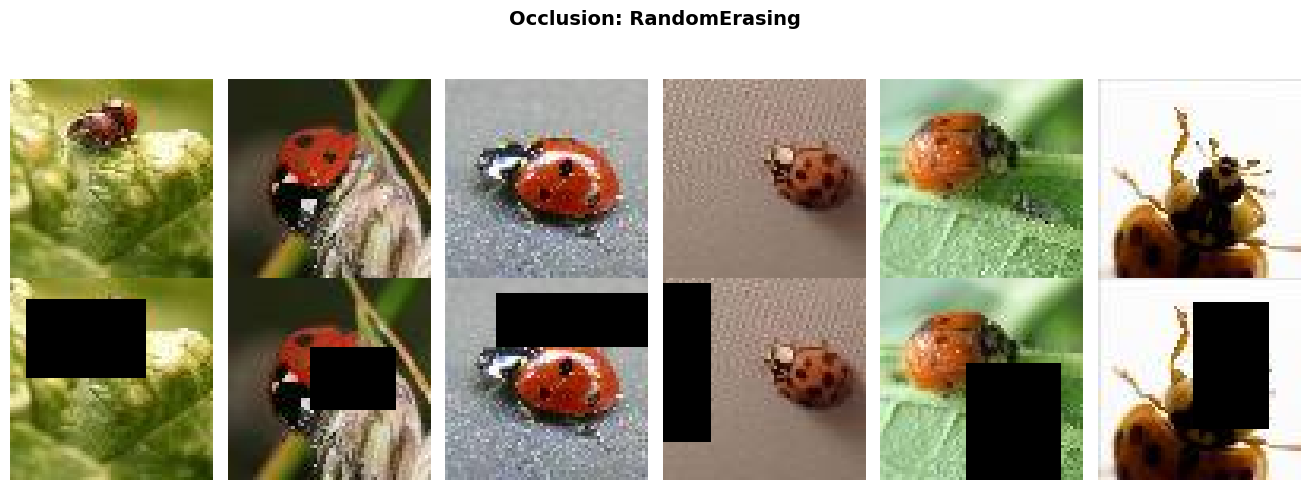

In [33]:
# RandomErasing works on tensors, so ToTensor is applied first
erasing_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomErasing(p=1.0, scale=(0.1, 0.3), ratio=(0.3, 3.3), value=0),
])

def show_erasing_grid(transform, dataset, num_images=6):
    fig, axs = plt.subplots(2, num_images, figsize=(num_images * 2.2, 5))
    fig.suptitle('Occlusion: RandomErasing', fontsize=14, fontweight='bold')

    for i in range(num_images):
        pil_img, _ = dataset[i]
        img_tensor = transform(pil_img)
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)

        axs[0, i].imshow(pil_img)
        axs[0, i].axis('off')
        axs[1, i].imshow(img_np)
        axs[1, i].axis('off')

    axs[0, 0].set_ylabel('Original', fontsize=10)
    axs[1, 0].set_ylabel('Erased', fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

show_erasing_grid(erasing_transform, raw_dataset)

## 3. Basic Augmentation Pipeline with `torchvision.transforms`

`torchvision.transforms` is the standard starting point for image augmentation in PyTorch. Transforms are chained using `Compose` and applied every time an image is loaded, introducing randomness during training while keeping validation deterministic.

In [34]:
# Tiny ImageNet-200 dataset statistics
TINY_IMAGENET_MEAN = (0.4802, 0.4481, 0.3975)
TINY_IMAGENET_STD = (0.2302, 0.2265, 0.2262)

# Training pipeline: augment then normalize
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=8),  # Changed from 32 to 64, padding from 4 to 8
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(TINY_IMAGENET_MEAN, TINY_IMAGENET_STD)
])

# Validation pipeline: normalize only (no augmentation)
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(TINY_IMAGENET_MEAN, TINY_IMAGENET_STD)
])

# Load datasets (make sure you've downloaded and extracted tiny-imagenet-200)
data_root = './data/tiny-imagenet-200'
train_dataset = ImageFolder(root=os.path.join(data_root, 'train'), transform=train_transforms)
val_dataset = ImageFolder(root=os.path.join(data_root, 'val'), transform=val_transforms)

# Build data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples   : {len(train_dataset):,}")
print(f"Validation samples : {len(val_dataset):,}")
print(f"Training batches   : {len(train_loader):,}")
print(f"Validation batches : {len(val_loader):,}")
print(f"Number of classes  : {len(train_dataset.classes)}")

Training samples   : 100,000
Validation samples : 10,000
Training batches   : 1,563
Validation batches : 157
Number of classes  : 200


### 3.1 Visualizing Augmented vs Original Images

Always inspect augmented images visually before training. This is the simplest way to catch errors like excessive cropping, broken colors, or wrong normalization.

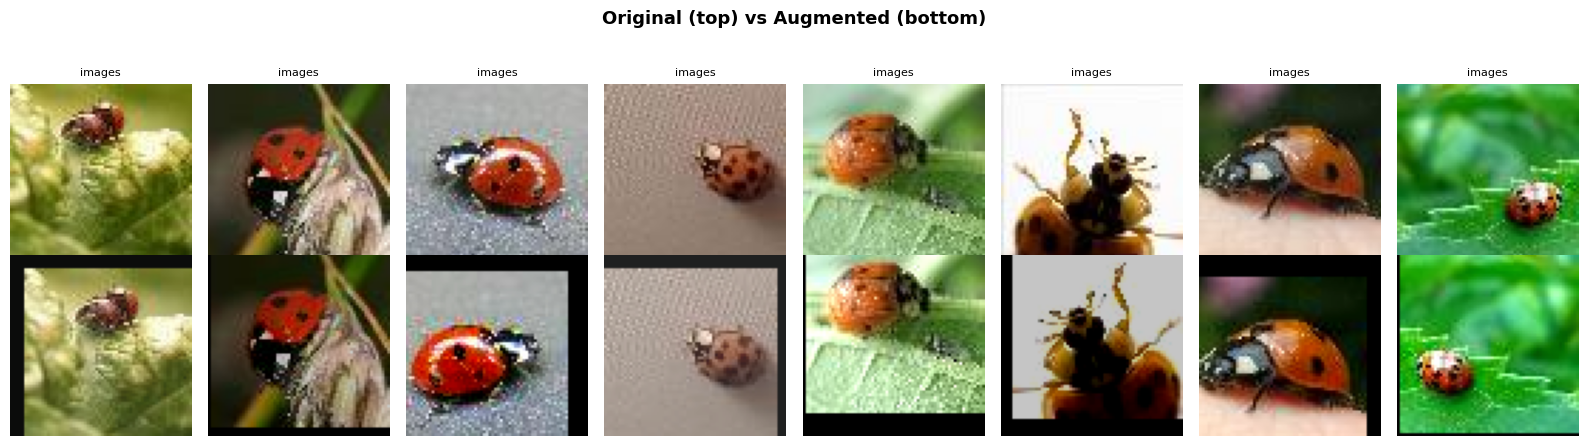

In [35]:
def unnormalize(img_tensor, mean=TINY_IMAGENET_MEAN, std=TINY_IMAGENET_STD):
    """Reverse normalization so a tensor can be displayed as an image."""
    mean = np.array(mean)
    std  = np.array(std)
    img  = img_tensor.numpy().transpose((1, 2, 0))  # CHW -> HWC
    img  = std * img + mean
    return np.clip(img, 0, 1)


def show_augmented_vs_original(aug_transform, raw_dataset, num_images=8):
    """
    Display original PIL images (top row) alongside their augmented tensors (bottom row).
    Requires raw_dataset without any transforms applied.
    """
    fig, axs = plt.subplots(2, num_images, figsize=(num_images * 2, 4.5))
    fig.suptitle('Original (top) vs Augmented (bottom)', fontsize=13, fontweight='bold')

    for i in range(num_images):
        pil_img, label = raw_dataset[i]
        aug_tensor     = aug_transform(pil_img)   # returns a normalized tensor
        class_name     = raw_dataset.classes[label]

        axs[0, i].imshow(pil_img)
        axs[0, i].set_title(class_name, fontsize=8)
        axs[0, i].axis('off')

        axs[1, i].imshow(unnormalize(aug_tensor))
        axs[1, i].axis('off')

    axs[0, 0].set_ylabel('Original',  fontsize=9)
    axs[1, 0].set_ylabel('Augmented', fontsize=9)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


show_augmented_vs_original(train_transforms, raw_dataset)

### 3.2 Verifying Stochasticity

Since transforms are applied randomly each time an image is loaded, the same image should look different across multiple epochs. The cell below confirms this by applying the same transform pipeline three times to the same image.

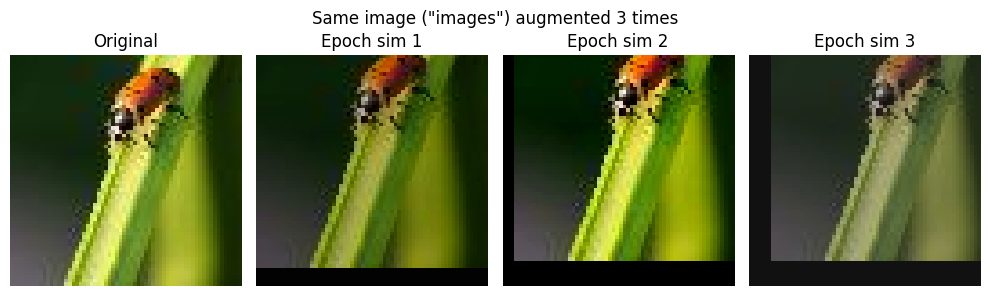

In [36]:
pil_img, label = raw_dataset[42]
fig, axs = plt.subplots(1, 4, figsize=(10, 3))
fig.suptitle(f'Same image ("{raw_dataset.classes[label]}") augmented 3 times', fontsize=12)

axs[0].imshow(pil_img)
axs[0].set_title('Original')
axs[0].axis('off')

for j in range(1, 4):
    aug = unnormalize(train_transforms(pil_img))
    axs[j].imshow(aug)
    axs[j].set_title(f'Epoch sim {j}')
    axs[j].axis('off')

plt.tight_layout()
plt.show()

## 4. The Modern API: `torchvision.transforms.v2`

Torchvision introduced `transforms.v2` to address several design limitations in the original API. Key improvements:

- **Unified behavior** — all operations work consistently across PIL images, tensors, bounding boxes, masks, and keypoints
- **Detection/segmentation ready** — supports spatial transforms on both image and annotation simultaneously
- **Better reproducibility** — improved seeding and state handling
- **GPU-ready design** — groundwork for future hardware-accelerated transforms

The API is nearly identical to v1, so migration requires minimal code changes.

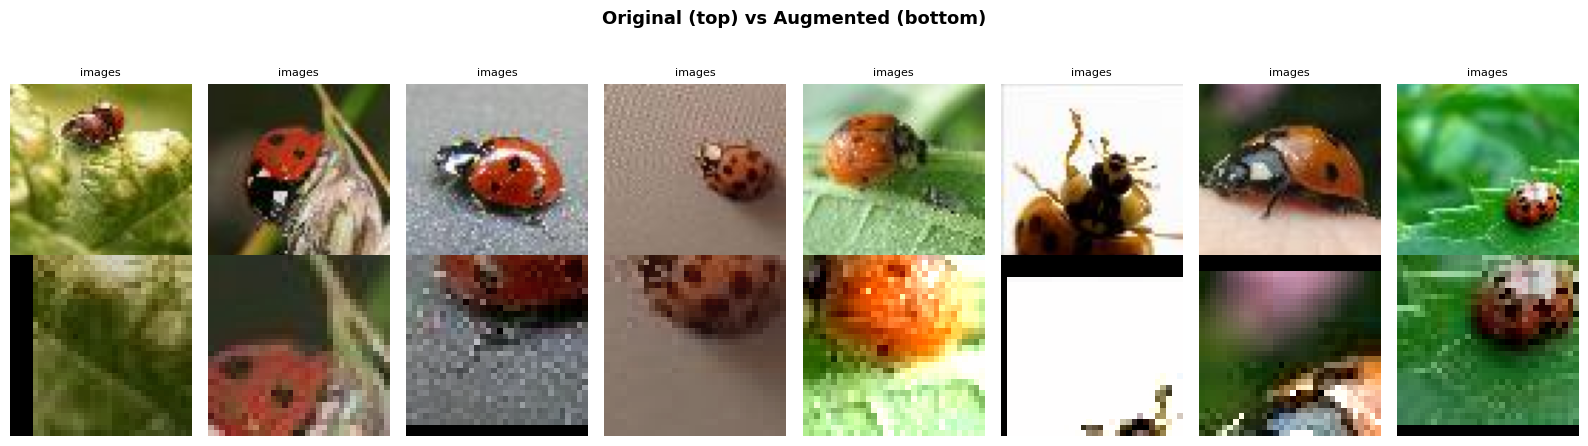

transforms.v2 pipeline verified.


In [38]:
import torchvision.transforms.v2 as transforms_v2

train_transforms_v2 = transforms_v2.Compose([
    transforms_v2.RandomHorizontalFlip(),
    transforms_v2.RandomCrop(32, padding=4),
    transforms_v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms_v2.ToTensor(),
    transforms_v2.Normalize(TINY_IMAGENET_MEAN, TINY_IMAGENET_STD)
])

# Apply to raw dataset — identical usage pattern to v1
show_augmented_vs_original(train_transforms_v2, raw_dataset)
print("transforms.v2 pipeline verified.")

### 4.1 v2 Additional Transforms Not in v1

`transforms.v2` introduces several transforms unavailable or inconsistent in the original API.

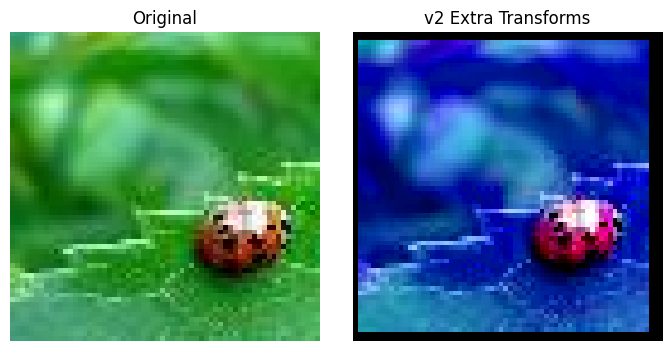

In [39]:
# Demonstration of v2-specific and enhanced transforms
v2_extra = transforms_v2.Compose([
    transforms_v2.RandomPhotometricDistort(p=1.0),  # photometric distortion bundle
    transforms_v2.RandomZoomOut(fill=0, side_range=(1.0, 1.5), p=1.0),
])

pil_img, _ = raw_dataset[7]
augmented  = v2_extra(pil_img)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))
axs[0].imshow(pil_img)
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(augmented)
axs[1].set_title('v2 Extra Transforms')
axs[1].axis('off')
plt.tight_layout()
plt.show()

## 5. Going Further: Albumentations

**Albumentations** is a fast, flexible library that operates on NumPy arrays rather than PIL images or PyTorch tensors. This makes it significantly faster in CPU-based pipelines.

Albumentations is especially well-suited for:
- Large-scale training pipelines where augmentation speed matters
- Tasks with structured annotations: segmentation masks, bounding boxes, keypoints
- Production systems requiring fine-grained control over transform probabilities

It integrates with PyTorch through `ToTensorV2`, which converts NumPy arrays to tensors in CHW format.

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define an Albumentations pipeline
alb_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.7),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    ToTensorV2()
])

# Apply to a single image
pil_img, label = raw_dataset[3]
image_np = np.array(pil_img)         # Albumentations expects HWC uint8 NumPy array

augmented   = alb_transform(image=image_np)
img_tensor  = augmented['image']     # CHW torch.Tensor (uint8)
img_display = img_tensor.permute(1, 2, 0).numpy()  # back to HWC for display

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(image_np)
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(img_display)
axs[1].set_title('Albumentations Augmented')
axs[1].axis('off')
plt.tight_layout()
plt.show()

### 5.1 Integrating Albumentations into a PyTorch Dataset

In [ ]:
from torch.utils.data import Dataset

class AlbumentationsCIFAR10(Dataset):
    """
    Wrapper around torchvision CIFAR-10 that applies an Albumentations
    pipeline instead of a torchvision transform.
    """
    def __init__(self, root, train=True, download=True, transform=None):
        self.base    = CIFAR10(root=root, train=train, download=download, transform=None)
        self.alb_transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        pil_img, label = self.base[idx]
        image_np = np.array(pil_img)
        if self.alb_transform:
            result   = self.alb_transform(image=image_np)
            image_np = result['image']
        return image_np, label


# Albumentations pipeline with normalization
alb_train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomCrop(32, 32),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, p=0.8),
    A.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    ToTensorV2()
])

alb_dataset = AlbumentationsCIFAR10(root='./data', train=True, transform=alb_train_transform)
alb_loader  = DataLoader(alb_dataset, batch_size=64, shuffle=True, num_workers=2)

sample_batch, sample_labels = next(iter(alb_loader))
print(f"Batch shape : {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")

### 5.2 Albumentations: Advanced Transforms

Albumentations provides many transforms not available in torchvision.

In [ ]:
# Showcase some advanced Albumentations transforms
advanced_transforms = [
    ('ElasticTransform',  A.ElasticTransform(alpha=30, sigma=5, p=1.0)),
    ('GridDistortion',    A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0)),
    ('CoarseDropout',     A.CoarseDropout(max_holes=8, max_height=4, max_width=4, p=1.0)),
    ('CLAHE',             A.CLAHE(clip_limit=4.0, p=1.0)),
]

pil_img, _ = raw_dataset[0]
image_np   = np.array(pil_img)

fig, axs = plt.subplots(1, len(advanced_transforms) + 1, figsize=(14, 3.5))
axs[0].imshow(image_np)
axs[0].set_title('Original')
axs[0].axis('off')

for j, (name, t) in enumerate(advanced_transforms):
    result = t(image=image_np)
    axs[j + 1].imshow(result['image'])
    axs[j + 1].set_title(name, fontsize=9)
    axs[j + 1].axis('off')

plt.suptitle('Advanced Albumentations Transforms', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 6. GPU-Accelerated Augmentation: Kornia

**Kornia** is fully PyTorch-native. It operates on tensors and runs on GPU. More importantly, its transforms are **differentiable**, meaning gradients can flow through them.

This makes Kornia essential for:
- In-loop batch augmentation on GPU (no CPU-GPU transfer overhead)
- Contrastive learning (e.g., SimCLR — two views of the same image)
- Adversarial training and domain adaptation
- Any workflow where augmentation must be part of the computation graph

In [ ]:
import kornia.augmentation as K

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load one image as a tensor
to_tensor_ds = CIFAR10(root='./data', train=True, download=True,
                        transform=transforms.ToTensor())

img_tensor, label = to_tensor_ds[0]
img_batch = img_tensor.unsqueeze(0).to(device)  # (1, C, H, W)

# Define Kornia augmentation sequence
kornia_aug = K.AugmentationSequential(
    K.RandomHorizontalFlip(p=1.0),
    K.RandomRotation(degrees=30.0),
    K.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1),
    data_keys=None  # images only (no masks/boxes)
).to(device)

def tensor_to_display(t):
    """Convert CHW tensor [0,1] to HWC uint8 for matplotlib."""
    arr = t.squeeze().cpu().permute(1, 2, 0).numpy()
    return np.clip(arr, 0, 1)

with torch.no_grad():
    aug_batch = kornia_aug(img_batch)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))
axs[0].imshow(tensor_to_display(img_batch))
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(tensor_to_display(aug_batch))
axs[1].set_title('Kornia Augmented')
axs[1].axis('off')
plt.tight_layout()
plt.show()

### 6.1 Kornia in a Training Loop (Batch-Level GPU Augmentation)

The primary pattern with Kornia is to apply augmentations inside the training loop on each batch, after it has been moved to GPU. This avoids the bottleneck of augmenting each image individually on CPU.

In [ ]:
# Minimal GPU training loop skeleton with Kornia batch-level augmentation
import torch.nn as nn

# Placeholder model
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(3, 10)

    def forward(self, x):
        return self.fc(self.pool(x).squeeze(-1).squeeze(-1))


model     = TinyNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Kornia augmentation runs on each batch inside the loop
batch_augment = K.AugmentationSequential(
    K.RandomHorizontalFlip(p=0.5),
    K.RandomCrop((32, 32), padding=4),
    data_keys=None
).to(device)

# Single training step demonstration (one batch)
raw_loader = DataLoader(
    CIFAR10(root='./data', train=True, transform=transforms.ToTensor(), download=False),
    batch_size=64, shuffle=True
)

images, labels = next(iter(raw_loader))
images, labels = images.to(device), labels.to(device)

# Augment on GPU
with torch.no_grad():
    images_aug = batch_augment(images)

optimizer.zero_grad()
outputs = model(images_aug)
loss    = criterion(outputs, labels)
loss.backward()
optimizer.step()

print(f"Batch shape after Kornia augmentation: {images_aug.shape}")
print(f"Training step loss: {loss.item():.4f}")

### 6.2 Library Comparison Summary

| Feature | torchvision.transforms | Albumentations | Kornia |
|---|---|---|---|
| Input format | PIL / Tensor | NumPy HWC | Tensor (GPU) |
| GPU support | No | No | Yes |
| Differentiable | No | No | Yes |
| Bounding box / mask support | Limited (v2) | Yes | Yes |
| Speed (CPU) | Moderate | Fast | N/A |
| Best use case | Standard pipelines | Production CV, detection | Research, contrastive learning |

---

## 7. Sample Mixing Strategies

Sample mixing techniques create new training examples by combining multiple images and their labels. Unlike single-image transforms, these change what a label *means*. This has powerful regularization effects.

### 7.1 Mixup

Mixup linearly interpolates two images and their labels:

```
mixed_image = lambda * x1 + (1 - lambda) * x2
mixed_label = lambda * y1 + (1 - lambda) * y2
```

The mixing coefficient `lambda` is sampled from a Beta distribution. This softens decision boundaries and forces the model to account for ambiguity between classes.

In [ ]:
import torch.nn.functional as F

def mixup_data(x, y, alpha=0.4, num_classes=10):
    """
    Apply Mixup to a batch.
    Returns mixed inputs and mixed soft labels (one-hot).
    """
    lam   = torch.distributions.Beta(alpha, alpha).sample().item()
    index = torch.randperm(x.size(0))

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a     = F.one_hot(y,         num_classes=num_classes).float()
    y_b     = F.one_hot(y[index],  num_classes=num_classes).float()
    mixed_y = lam * y_a + (1 - lam) * y_b

    return mixed_x, mixed_y, lam


# Visualize Mixup
to_tensor_ds = CIFAR10(root='./data', train=True, transform=transforms.ToTensor(), download=False)
loader_small = DataLoader(to_tensor_ds, batch_size=8, shuffle=True)
batch_imgs, batch_labels = next(iter(loader_small))

mixed_imgs, mixed_labels, lam = mixup_data(batch_imgs, batch_labels)

fig, axs = plt.subplots(2, 8, figsize=(16, 4.5))
fig.suptitle(f'Mixup  (lambda = {lam:.2f})', fontsize=12, fontweight='bold')

for i in range(8):
    axs[0, i].imshow(batch_imgs[i].permute(1, 2, 0).numpy())
    axs[0, i].set_title(to_tensor_ds.classes[batch_labels[i].item()], fontsize=7)
    axs[0, i].axis('off')

    axs[1, i].imshow(mixed_imgs[i].permute(1, 2, 0).numpy())
    top2 = mixed_labels[i].topk(2).indices
    label_str = f"{to_tensor_ds.classes[top2[0].item()]} / {to_tensor_ds.classes[top2[1].item()]}"
    axs[1, i].set_title(label_str, fontsize=6)
    axs[1, i].axis('off')

axs[0, 0].set_ylabel('Original',  fontsize=9)
axs[1, 0].set_ylabel('Mixed',     fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### 7.2 CutMix

CutMix cuts a rectangular patch from one image and pastes it into another. Labels are mixed proportionally to the area of the patch. This forces the model to use global context rather than focusing on a single region.

In [ ]:
def cutmix_data(x, y, alpha=1.0, num_classes=10):
    """
    Apply CutMix to a batch.
    Returns images with a patch from another image pasted in,
    and soft labels proportional to the pasted area.
    """
    lam   = torch.distributions.Beta(alpha, alpha).sample().item()
    index = torch.randperm(x.size(0))
    _, C, H, W = x.shape

    # Compute cut region
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = max(cx - cut_w // 2, 0)
    y1 = max(cy - cut_h // 2, 0)
    x2 = min(cx + cut_w // 2, W)
    y2 = min(cy + cut_h // 2, H)

    mixed_x = x.clone()
    mixed_x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]

    # Adjust lambda to reflect actual area ratio
    lam_actual = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    y_a = F.one_hot(y,        num_classes=num_classes).float()
    y_b = F.one_hot(y[index], num_classes=num_classes).float()
    mixed_y = lam_actual * y_a + (1 - lam_actual) * y_b

    return mixed_x, mixed_y, lam_actual


batch_imgs, batch_labels = next(iter(loader_small))
cut_imgs, cut_labels, cut_lam = cutmix_data(batch_imgs, batch_labels)

fig, axs = plt.subplots(2, 8, figsize=(16, 4.5))
fig.suptitle(f'CutMix  (lambda = {cut_lam:.2f})', fontsize=12, fontweight='bold')

for i in range(8):
    axs[0, i].imshow(batch_imgs[i].permute(1, 2, 0).numpy())
    axs[0, i].set_title(to_tensor_ds.classes[batch_labels[i].item()], fontsize=7)
    axs[0, i].axis('off')

    axs[1, i].imshow(cut_imgs[i].permute(1, 2, 0).numpy())
    top2 = cut_labels[i].topk(2).indices
    label_str = f"{to_tensor_ds.classes[top2[0].item()]} / {to_tensor_ds.classes[top2[1].item()]}"
    axs[1, i].set_title(label_str, fontsize=6)
    axs[1, i].axis('off')

axs[0, 0].set_ylabel('Original',  fontsize=9)
axs[1, 0].set_ylabel('CutMixed',  fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### 7.3 Cutout

Cutout removes a fixed square region from each image (filled with zeros or a constant value). The label is unchanged. This acts like spatial dropout and prevents the model from over-relying on any single image region.

In [ ]:
def cutout(x, n_holes=1, length=8, fill_value=0.0):
    """
    Apply Cutout to a batch of images.
    Randomly erases n_holes rectangles of size (length x length).
    """
    B, C, H, W = x.shape
    mask = torch.ones_like(x)

    for _ in range(n_holes):
        cy = np.random.randint(H)
        cx = np.random.randint(W)

        y1 = max(cy - length // 2, 0)
        y2 = min(cy + length // 2, H)
        x1 = max(cx - length // 2, 0)
        x2 = min(cx + length // 2, W)

        mask[:, :, y1:y2, x1:x2] = 0

    return x * mask + fill_value * (1 - mask)


batch_imgs, batch_labels = next(iter(loader_small))
cut_out_imgs = cutout(batch_imgs, n_holes=2, length=10)

fig, axs = plt.subplots(2, 8, figsize=(16, 4.5))
fig.suptitle('Cutout (2 holes, length=10)', fontsize=12, fontweight='bold')

for i in range(8):
    axs[0, i].imshow(batch_imgs[i].permute(1, 2, 0).numpy())
    axs[0, i].set_title(to_tensor_ds.classes[batch_labels[i].item()], fontsize=7)
    axs[0, i].axis('off')

    axs[1, i].imshow(cut_out_imgs[i].permute(1, 2, 0).clamp(0, 1).numpy())
    axs[1, i].axis('off')

axs[0, 0].set_ylabel('Original', fontsize=9)
axs[1, 0].set_ylabel('Cutout',   fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### 7.4 Integrating Mixup / CutMix into a Training Loop

These techniques require using **soft labels** (probability distributions) instead of hard integer class indices. This means using `CrossEntropyLoss` with soft targets, or a custom loss wrapper.

In [ ]:
def soft_cross_entropy(logits, soft_targets):
    """
    Cross entropy loss that accepts soft (non-integer) label distributions.
    Equivalent to -sum(soft_targets * log_softmax(logits), dim=1).mean()
    """
    log_probs = F.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()


def training_step_with_mixup(model, images, labels, optimizer, alpha=0.4):
    """
    One training step using Mixup augmentation and soft cross-entropy.
    """
    mixed_images, mixed_labels, _ = mixup_data(images, labels, alpha=alpha)

    optimizer.zero_grad()
    logits = model(mixed_images)
    loss   = soft_cross_entropy(logits, mixed_labels)
    loss.backward()
    optimizer.step()

    return loss.item()


# Quick verification
batch_imgs, batch_labels = next(iter(raw_loader))
loss_val = training_step_with_mixup(model, batch_imgs.to(device),
                                    batch_labels.to(device), optimizer)
print(f"Mixup training step loss: {loss_val:.4f}")

## 8. Policy-Based and Learned Augmentation

Rather than choosing augmentations manually, policy-based methods learn or search for optimal strategies.

### 8.1 AutoAugment

AutoAugment uses reinforcement learning to discover augmentation policies. A policy consists of sub-policies — each a sequence of transforms with associated probabilities and magnitudes. The policy that maximizes validation accuracy on a proxy task is selected.

PyTorch provides pre-discovered policies for CIFAR-10 and ImageNet via `transforms.AutoAugment`.

In [ ]:
from torchvision.transforms import AutoAugmentPolicy

# CIFAR-10 policy (discovered via RL on CIFAR-10)
auto_augment = transforms.AutoAugment(policy=AutoAugmentPolicy.CIFAR10)

show_transform_grid(auto_augment, raw_dataset, title='AutoAugment (CIFAR-10 Policy)')

### 8.2 RandAugment

RandAugment simplifies AutoAugment by randomly sampling `N` transforms from a fixed pool and applying them at a global magnitude `M`. These two hyperparameters are tuned manually or by grid search. Despite being simpler, RandAugment achieves competitive results.

In [ ]:
# N = number of transforms to apply, M = magnitude [0, 30]
rand_augment = transforms.RandAugment(num_ops=2, magnitude=9)

show_transform_grid(rand_augment, raw_dataset, title='RandAugment (N=2, M=9)')

### 8.3 AugMix

AugMix applies multiple augmentation chains in parallel and mixes their outputs with the original image. It is designed to improve robustness to distribution shift and out-of-distribution inputs while maintaining consistent predictions.

In [ ]:
aug_mix = transforms.AugMix(severity=3, mixture_width=3, chain_depth=-1)

show_transform_grid(aug_mix, raw_dataset, title='AugMix (severity=3, width=3)')

### 8.4 Comparing Policy-Based Strategies

In [ ]:
policies = {
    'AutoAugment': transforms.AutoAugment(AutoAugmentPolicy.CIFAR10),
    'RandAugment': transforms.RandAugment(num_ops=2, magnitude=9),
    'AugMix':      transforms.AugMix(severity=3, mixture_width=3),
}

pil_img, label = raw_dataset[5]
fig, axs = plt.subplots(1, len(policies) + 1, figsize=(12, 3.5))
axs[0].imshow(pil_img)
axs[0].set_title('Original')
axs[0].axis('off')

for j, (name, policy) in enumerate(policies.items()):
    axs[j + 1].imshow(policy(pil_img))
    axs[j + 1].set_title(name, fontsize=9)
    axs[j + 1].axis('off')

plt.suptitle(f'Policy-Based Augmentation — class: {raw_dataset.classes[label]}',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

## 9. Building a Full Training Pipeline

This section assembles a complete, production-style pipeline combining torchvision transforms with Mixup and a simple CNN. The goal is to show how each component fits together.

In [ ]:
import torch.nn as nn

# Simple baseline CNN for CIFAR-10
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total


def train_epoch(model, loader, optimizer, criterion, device, use_mixup=False, alpha=0.4):
    model.train()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if use_mixup:
            images, soft_labels, _ = mixup_data(images, labels, alpha=alpha)
            optimizer.zero_grad()
            loss = soft_cross_entropy(model(images), soft_labels)
        else:
            optimizer.zero_grad()
            loss = criterion(model(images), labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


print("Model and training functions defined.")
total_params = sum(p.numel() for p in SimpleCNN().parameters())
print(f"SimpleCNN parameters: {total_params:,}")

In [ ]:
# Train two models: without augmentation vs with augmentation + Mixup
# NOTE: This is a short run (5 epochs) for demonstration.
# Increase NUM_EPOCHS to see the full benefit of augmentation.

NUM_EPOCHS = 5

# --- Baseline: no augmentation ---
baseline_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])
baseline_ds     = CIFAR10(root='./data', train=True,  transform=baseline_transforms, download=False)
baseline_loader = DataLoader(baseline_ds, batch_size=128, shuffle=True, num_workers=2)

model_baseline = SimpleCNN().to(device)
opt_baseline   = torch.optim.Adam(model_baseline.parameters(), lr=1e-3)
criterion_base = nn.CrossEntropyLoss()

# --- Augmented: standard transforms + Mixup ---
aug_ds     = CIFAR10(root='./data', train=True, transform=train_transforms, download=False)
aug_loader = DataLoader(aug_ds, batch_size=128, shuffle=True, num_workers=2)

model_aug = SimpleCNN().to(device)
opt_aug   = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

# Shared validation loader
val_ds   = CIFAR10(root='./data', train=False, transform=val_transforms, download=False)
val_load = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=2)

history = {'baseline_loss': [], 'aug_loss': [],
           'baseline_val': [],  'aug_val': []}

for epoch in range(1, NUM_EPOCHS + 1):
    bl = train_epoch(model_baseline, baseline_loader, opt_baseline, criterion_base,
                     device, use_mixup=False)
    al = train_epoch(model_aug,      aug_loader,      opt_aug,      criterion_base,
                     device, use_mixup=True, alpha=0.4)

    bv = evaluate(model_baseline, val_load, device)
    av = evaluate(model_aug,      val_load, device)

    history['baseline_loss'].append(bl)
    history['aug_loss'].append(al)
    history['baseline_val'].append(bv)
    history['aug_val'].append(av)

    print(f"Epoch {epoch}/{NUM_EPOCHS}  "
          f"Baseline: loss={bl:.3f} val_acc={bv:.3f}  |  "
          f"Augmented: loss={al:.3f} val_acc={av:.3f}")

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(epochs, history['baseline_loss'], 'o-', label='Baseline (no aug)', color='steelblue')
ax1.plot(epochs, history['aug_loss'],      's-', label='Augmented + Mixup', color='darkorange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, history['baseline_val'], 'o-', label='Baseline (no aug)', color='steelblue')
ax2.plot(epochs, history['aug_val'],      's-', label='Augmented + Mixup', color='darkorange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validation Accuracy Comparison')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Effect of Data Augmentation on Training', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

---

## 10. Testing Whether Augmentation Is Helping

Adding augmentation does not always improve results. It is important to measure its effect systematically.

**Key signals to monitor:**

- Training loss is higher with augmentation (expected — the task is harder)
- Validation accuracy is higher with augmentation (this is the goal)
- The gap between training and validation accuracy narrows (less overfitting)

**Common failure modes:**

- Augmentation is too aggressive — the model cannot learn at all
- Augmentations break the label (e.g., flipping text or rotating digits)
- The transforms are applied to validation data (they should not be)
- Inconsistency between training and inference image preprocessing

In [ ]:
# Overfitting diagnostic: training vs validation accuracy gap

def compute_train_acc(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total


train_acc_baseline = compute_train_acc(model_baseline, baseline_loader, device)
train_acc_aug      = compute_train_acc(model_aug,      aug_loader,      device)
val_acc_baseline   = history['baseline_val'][-1]
val_acc_aug        = history['aug_val'][-1]

print("=" * 52)
print(f"{'Model':<20} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}")
print("-" * 52)
print(f"{'Baseline':<20} {train_acc_baseline:>10.3f} {val_acc_baseline:>10.3f} "
      f"{train_acc_baseline - val_acc_baseline:>8.3f}")
print(f"{'Augmented + Mixup':<20} {train_acc_aug:>10.3f} {val_acc_aug:>10.3f} "
      f"{train_acc_aug - val_acc_aug:>8.3f}")
print("=" * 52)
print("A smaller gap indicates less overfitting.")

In [ ]:
# Per-class accuracy to check if augmentation hurts any particular class
def per_class_accuracy(model, loader, classes, device):
    class_correct = {c: 0 for c in classes}
    class_total   = {c: 0 for c in classes}

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            for pred, label in zip(preds, labels):
                c = classes[label.item()]
                class_total[c]   += 1
                class_correct[c] += int(pred == label)

    return {c: class_correct[c] / max(class_total[c], 1) for c in classes}


classes_list = raw_dataset.classes
acc_base = per_class_accuracy(model_baseline, val_load, classes_list, device)
acc_aug  = per_class_accuracy(model_aug,      val_load, classes_list, device)

# Bar chart comparison
x = np.arange(len(classes_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, [acc_base[c] for c in classes_list],
               width, label='Baseline', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, [acc_aug[c] for c in classes_list],
               width, label='Augmented + Mixup', color='darkorange', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(classes_list, rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Validation Accuracy: Baseline vs Augmented', fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Augmentation Selection Guidelines

| Situation | Recommended Strategy |
|---|---|
| Small dataset, classification | Geometric + color transforms + Mixup/CutMix |
| Object detection / segmentation | Albumentations with box/mask-aware transforms |
| Need GPU-speed augmentation | Kornia batch augmentation inside training loop |
| Want automated policy selection | RandAugment or AutoAugment |
| Robustness to distribution shift | AugMix |
| Contrastive / self-supervised learning | Kornia (differentiable, two views of same image) |
| Research / gradient through augmentation | Kornia |

**General rules:**

- Always validate augmentations visually before training
- Never apply stochastic augmentation to validation or test data
- Monitor the train/val accuracy gap — a narrowing gap confirms augmentation is helping
- Combine multiple techniques carefully; more augmentation is not always better
- Augmentation works best when combined with an appropriate learning rate and batch size